In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field

In [2]:
load_dotenv()

groq_llm = ChatGroq(
    model_name = "llama-3.3-70b-versatile",
    temperature=0.5
)

llama_llm = ChatOllama(
    base_url="http://localhost:11434",
    model = "llama3.2",
    temperature=0.6
)

In [3]:
class TweetevaluationSchema(BaseModel):
    evaluation: Literal["Approved", "Needs Improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(...,description="feedback for the post.")

In [4]:
eval_llm = groq_llm.with_structured_output(TweetevaluationSchema)

In [5]:
# State
class PGState(TypedDict):
    topic: str
    post: str
    context: str
    evaluation: Literal["Approved", "Needs Improvement"]
    feedback: str
    iteration: int
    max_iteration: int


In [6]:
graph = StateGraph(PGState)

In [7]:
def MakePost(state: PGState):

    messages = [
        SystemMessage(content="You are a clear, thoughtful LinkedIn creator who shares learning journeys   and projects in a professional, grounded, and easy-to-understand way."),
        
        HumanMessage(content=f"""
        Write a LinkedIn post about my learning journey or a project I recently built on the topic: "{state['topic']}".

        Context you can use (if provided):
        {state.get('context', '')}

        Rules:
        - Keep the tone professional, simple, and reflective
        - Focus on what I learned, built, or explored
        - Explain the project or concept clearly in plain English
        - Highlight key features or takeaways (use bullet points if useful)
        - Avoid hype, exaggeration, or buzzwords
        - Use short paragraphs for readability
        - Do not overuse emojis (prefer none)
        - End with a brief forward-looking or reflective closing
        - Add 3-5 relevant hashtags

        Strict Output Rules:
        - Output ONLY the final post content
        - Do NOT add any introduction like "Here is your post"
        - Do NOT add any explanation before or after the post
        - Do NOT mention AI, generation, or writing process
        - Do NOT use quotes around the post

        Structure:
        1. What I started learning or building
        2. What I built or explored
        3. Key takeaways or features
        4. Reflection or next steps
        5. Hashtags
        """)
    ]

    post = llama_llm.invoke(messages).content

    return {'post': post}



In [8]:
def EvaluatePost(state: PGState):
    # Prompt
    messages = [
        SystemMessage(content="You are a sharp, no-nonsense LinkedIn content critic. You evaluate posts based on clarity, authenticity, structure, and professional value."),
        
        HumanMessage(content=f"""
            Evaluate the following LinkedIn post:

            Post: "{state['post']}"

            Use the criteria below to evaluate the post:

            1. Clarity - Is the idea explained clearly and easy to follow?
            2. Authenticity - Does it feel genuine and grounded, or generic and performative?
            3. Value - Does it provide meaningful insights, learnings, or takeaways?
            4. Structure - Is it well-organized with good flow and readable formatting?
            5. Engagement Potential - Would this make someone pause, read, or engage?

            Auto-reject if:
            - It is overly generic or reads like a template with no real insight
            - It uses excessive buzzwords or hype language
            - It lacks a clear learning, takeaway, or outcome
            - It is poorly structured or hard to read (long blocks, no flow)
            - It feels self-promotional without substance

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs improvement"
            - feedback: One paragraph explaining the strengths and weaknesses
        """)
    ]

    # llm result
    result = eval_llm.invoke(messages)
    # save it
    return {'evaluation': result.evaluation, 'feedback': result.feedback}




In [9]:
def OptimizePost(state: PGState):
    messages = [
        SystemMessage(content="You refine LinkedIn posts to improve clarity, authenticity, structure, and professional value based on feedback."),
        
        HumanMessage(content=f"""
            Improve the LinkedIn post based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"

            Original Post:
            {state['post']}

            Rewrite it as a clear, well-structured LinkedIn post.

            Rules:
            - Keep the tone professional, simple, and reflective
            - Improve clarity and flow
            - Make the learning or project more concrete and specific
            - Strengthen key takeaways or insights
            - Avoid buzzwords, hype, or generic statements
            - Use short paragraphs and bullet points if helpful
            - Keep it concise but complete
            - Do not overuse emojis (prefer none)
            - End with a thoughtful closing line
            - Add 3-5 relevant hashtags

            Strict Output Rules:
            - Output ONLY the final post content
            - Do NOT add any introduction like "Here is your post"
            - Do NOT add any explanation before or after the post
            - Do NOT mention AI, generation, or writing process
            - Do NOT use quotes around the post
        """)
    ]

    result = groq_llm.invoke(messages).content
    state['iteration'] += 1
    return {'post': result}



In [10]:
def check_post(state: PGState):
    if state['evaluation'].lower() == 'approved' or state['iteration'] >= state['max_iteration']:
        return "Approved"
    elif state['evaluation'].lower() == "needs improvement":
        return "Optimize"
    

In [11]:
graph.add_node("Make_Post", MakePost)
graph.add_node("Evaluate_Post", EvaluatePost)
graph.add_node("Optimize_Post", OptimizePost)

In [12]:
graph.add_edge(START, "Make_Post")
graph.add_edge("Make_Post","Evaluate_Post")
graph.add_conditional_edges("Evaluate_Post",check_post, {"Approved":END, "Optimize":"Optimize_Post"})
graph.add_edge("Optimize_Post","Evaluate_Post")

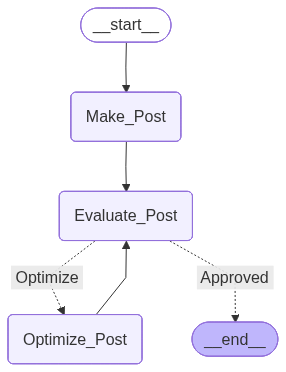

In [13]:
workflow = graph.compile()
workflow

In [14]:
initial_state = {
    "topic":"AI", 
    "iteration" : 1,
    "max_iteration": 5
    }
final_state = workflow.invoke(initial_state)

In [15]:
print(final_state['post'])
print("-"*50)
print(final_state['feedback'])
print("-"*50)
print(final_state['evaluation'])
print("-"*50)
print(final_state['iteration'])

As I delved into understanding the capabilities of machine learning, I began to explore how it can be applied in real-world scenarios.

I recently worked on building a chatbot that utilizes natural language processing (NLP) to provide customer support. The goal was to create a conversational interface that can understand and respond to user queries in a helpful manner.

Here are some key features of the project:
• I used the TensorFlow library to build the NLP model, which allowed me to analyze and understand user input.
• I implemented a sentiment analysis tool to determine the tone and emotions behind user queries.
• The chatbot is integrated with a database that stores customer information, allowing for personalized responses.

Through this project, I gained valuable insights into the importance of data preprocessing, model selection, and hyperparameter tuning. I also learned about the challenges of handling ambiguity and uncertainty in natural language inputs.

As I continue to exp